In [30]:
# ==========================================================
# Cell 1 : Imports
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
import pandas as pd

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [10]:
# ==========================================================
# Cell 2 : Device
# ==========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

a = torch.randn(2,2).cuda()

print(a)

True
NVIDIA GeForce RTX 4060 Laptop GPU
tensor([[-0.0491, -0.3175],
        [ 0.0631, -0.0248]], device='cuda:0')


In [3]:
# ==========================================================
# Cell 3 : Paths
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "processed_data"

MODEL_DIR = PROJECT_ROOT / "saved_models"

RESULT_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULT_DIR / "metrics"
HISTORY_DIR = RESULT_DIR / "history"

MODEL_DIR.mkdir(exist_ok=True)

RESULT_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\ashut\Documents\Rainfall Prediction


In [4]:
# ==========================================================
# Cell 4 : Load Dataset
# ==========================================================

X_train = np.load(PROCESSED_DIR / "X_train.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")

X_val = np.load(PROCESSED_DIR / "X_val.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")

X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

Training : (6387, 7, 129, 135)
Validation : (1369, 7, 129, 135)
Testing : (1369, 7, 129, 135)


In [5]:
# ==========================================================
# Cell 5 : Imports
# ==========================================================

from utils.dataset import RainfallDataset
from utils.metrics import evaluate_model, print_metrics
from utils.early_stopping import EarlyStopping
from utils.trainer import train_one_epoch, validate

from models.cnn import CNNBaseline

print("Project Modules Imported Successfully")

Project Modules Imported Successfully


In [6]:
# ==========================================================
# Cell 6 : Dataset
# ==========================================================

train_dataset = RainfallDataset(
    X_train,
    y_train
)

val_dataset = RainfallDataset(
    X_val,
    y_val
)

test_dataset = RainfallDataset(
    X_test,
    y_test
)

print(len(train_dataset))

6387


In [7]:
# ==========================================================
# Cell 7 : DataLoader
# ==========================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Ready")

DataLoaders Ready


In [8]:
# ==========================================================
# Cell 8 : Verify Tensor Shapes
# ==========================================================

images, labels = next(iter(train_loader))

print("Images :", images.shape)
print("Labels :", labels.shape)

Images : torch.Size([8, 7, 1, 129, 135])
Labels : torch.Size([8, 1, 129, 135])


In [11]:
# ==========================================================
# Cell 9 : Build CNN
# ==========================================================

cnn_model = CNNBaseline().to(DEVICE)

print(cnn_model)

CNNBaseline(
  (cnn): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [12]:
# ==========================================================
# Cell 10 : Parameters
# ==========================================================

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Total Parameters      : 42,081
Trainable Parameters  : 42,081


In [13]:
# ==========================================================
# Cell 11 : Forward Pass Test
# ==========================================================

cnn_model.eval()

with torch.no_grad():

    output = cnn_model(images.to(DEVICE))

print("Input Shape  :", images.shape)
print("Output Shape :", output.shape)

Input Shape  : torch.Size([8, 7, 1, 129, 135])
Output Shape : torch.Size([8, 1, 129, 135])


In [14]:
# ==========================================================
# Cell 12 : Loss Function
# ==========================================================

criterion = nn.MSELoss()

print("Loss Function :", criterion)

Loss Function : MSELoss()


In [15]:
# ==========================================================
# Cell 13 : Optimizer
# ==========================================================

LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer Ready")

Optimizer Ready


In [17]:
# ==========================================================
# Cell 14 : Early Stopping
# ==========================================================

early_stopping = EarlyStopping(
    patience=5,
    delta=0
)

print("EarlyStopping Initialized")

EarlyStopping Initialized


In [18]:
# ==========================================================
# Cell 14 : Early Stopping
# ==========================================================

early_stopping = EarlyStopping(
    patience=5,
    delta=0
)

print("EarlyStopping Initialized")

EarlyStopping Initialized


In [19]:
# ==========================================================
# Cell 15 : Training Configuration
# ==========================================================

EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": []
}

best_loss = float("inf")

print("Training Configuration Ready!")

Training Configuration Ready!


In [20]:
# ==========================================================
# Cell 16 : CNN Training
# ==========================================================

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        cnn_model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss = validate(
        cnn_model,
        val_loader,
        criterion,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            cnn_model.state_dict(),
            MODEL_DIR / "cnn_baseline.pth"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(f"\nEarly stopping triggered at Epoch {epoch+1}")

        break
        

Epoch 01/30 | Train Loss: 0.001040 | Val Loss: 0.000076
Epoch 02/30 | Train Loss: 0.000042 | Val Loss: 0.000031
Epoch 03/30 | Train Loss: 0.000031 | Val Loss: 0.000029
Epoch 04/30 | Train Loss: 0.000030 | Val Loss: 0.000035
Epoch 05/30 | Train Loss: 0.000030 | Val Loss: 0.000031
Epoch 06/30 | Train Loss: 0.000029 | Val Loss: 0.000034
Epoch 07/30 | Train Loss: 0.000030 | Val Loss: 0.000028
Epoch 08/30 | Train Loss: 0.000030 | Val Loss: 0.000034
Epoch 09/30 | Train Loss: 0.000030 | Val Loss: 0.000035
Epoch 10/30 | Train Loss: 0.000030 | Val Loss: 0.000029
Epoch 11/30 | Train Loss: 0.000030 | Val Loss: 0.000027
Epoch 12/30 | Train Loss: 0.000029 | Val Loss: 0.000031
Epoch 13/30 | Train Loss: 0.000030 | Val Loss: 0.000029
Epoch 14/30 | Train Loss: 0.000029 | Val Loss: 0.000041
Epoch 15/30 | Train Loss: 0.000030 | Val Loss: 0.000033
Epoch 16/30 | Train Loss: 0.000029 | Val Loss: 0.000027
Epoch 17/30 | Train Loss: 0.000028 | Val Loss: 0.000036
Epoch 18/30 | Train Loss: 0.000028 | Val Loss: 0

In [21]:
# ==========================================================
# Cell 17 : Load Best Model
# ==========================================================

cnn_model.load_state_dict(
    torch.load(
        MODEL_DIR / "cnn_baseline.pth",
        map_location=DEVICE
    )
)

cnn_model.eval()

print("Best CNN Model Loaded!")

Best CNN Model Loaded!


In [22]:
# ==========================================================
# Cell 18 : Prediction
# ==========================================================

predictions = []
targets = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(DEVICE)

        pred = cnn_model(X)

        predictions.append(pred.cpu().numpy())

        targets.append(y.numpy())

print("Prediction Completed!")

Prediction Completed!


In [23]:
# ==========================================================
# Cell 19 : Convert Predictions
# ==========================================================

y_pred = np.concatenate(predictions, axis=0)

y_true = np.concatenate(targets, axis=0)

print("Prediction Shape :", y_pred.shape)
print("Ground Truth Shape :", y_true.shape)

Prediction Shape : (1369, 1, 129, 135)
Ground Truth Shape : (1369, 1, 129, 135)


In [24]:
# ==========================================================
# Cell 20 : Evaluation
# ==========================================================

metrics = evaluate_model(
    y_true,
    y_pred
)

print_metrics(metrics)

MAE     : 0.001727
MSE     : 0.000030
RMSE    : 0.005500
R2      : 0.297333


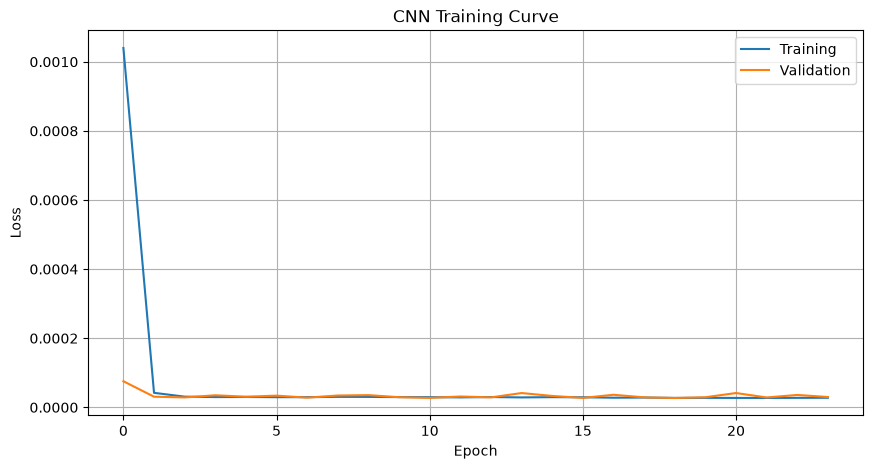

In [25]:
# ==========================================================
# Cell 21 : Training Curve
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Training"
)

plt.plot(
    history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Curve")

plt.grid(True)
plt.legend()

plt.show()

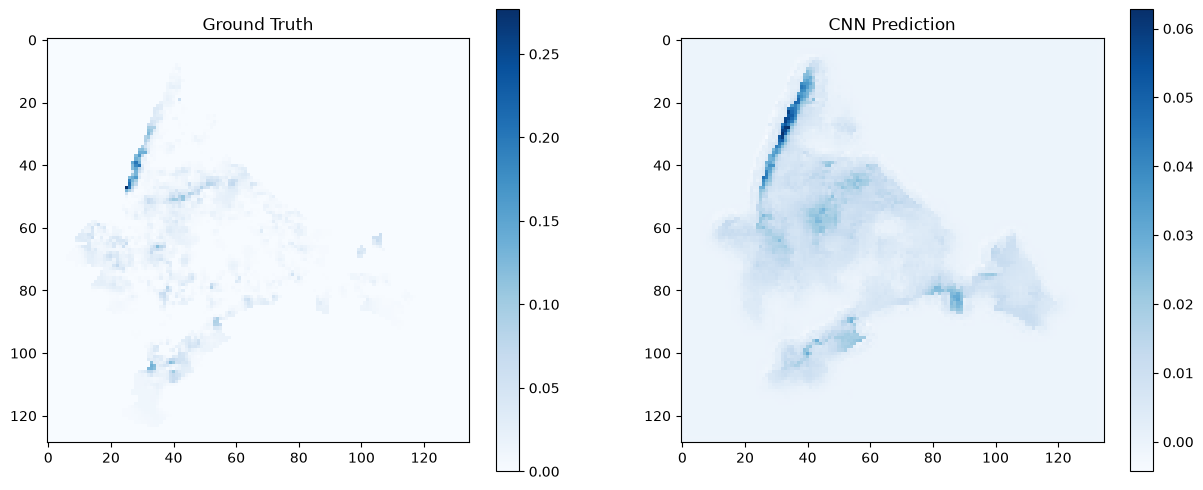

In [26]:
# ==========================================================
# Cell 22 : Prediction Visualization
# ==========================================================

sample = 100

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)

plt.imshow(
    y_true[sample][0],
    cmap="Blues"
)

plt.title("Ground Truth")
plt.colorbar()

plt.subplot(1,2,2)

plt.imshow(
    y_pred[sample][0],
    cmap="Blues"
)

plt.title("CNN Prediction")
plt.colorbar()

plt.show()

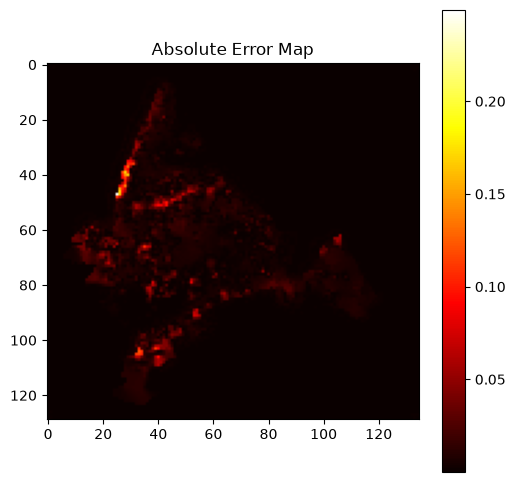

In [27]:
# ==========================================================
# Cell 23 : Absolute Error
# ==========================================================

difference = np.abs(
    y_true[sample][0] -
    y_pred[sample][0]
)

plt.figure(figsize=(6,6))

plt.imshow(
    difference,
    cmap="hot"
)

plt.title("Absolute Error Map")

plt.colorbar()

plt.show()

In [31]:
# ==========================================================
# Cell 24 : Save Training History
# ==========================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_DIR / "cnn_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [32]:
# ==========================================================
# Cell 25 : Save Metrics
# ==========================================================

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    METRICS_DIR / "cnn_metrics.csv",
    index=False
)

print("Metrics saved.")

Metrics saved.


In [33]:
# ==========================================================
# Notebook 2 Completed
# ==========================================================

print("="*60)
print("CNN BASELINE TRAINING COMPLETED")
print("="*60)

print(f"Best Validation Loss : {best_loss:.6f}")

print(f"Test MAE  : {metrics['MAE']:.6f}")
print(f"Test RMSE : {metrics['RMSE']:.6f}")
print(f"Test R²   : {metrics['R2']:.6f}")

print("\nSaved Files:")

print("✓ cnn_baseline.pth")
print("✔ metrics/cnn_metrics.csv")
print("✔ history/cnn_training_history.csv")

print("\nNotebook 2 Finished Successfully!")

CNN BASELINE TRAINING COMPLETED
Best Validation Loss : 0.000027
Test MAE  : 0.001727
Test RMSE : 0.005500
Test R²   : 0.297333

Saved Files:
✓ cnn_baseline.pth
✓ cnn_metrics.csv
✓ cnn_training_history.csv

Notebook 2 Finished Successfully!
